In [1]:
import pandas as pd
tracks = pd.read_csv('tracks.csv', low_memory=False)



tracks

,track_id,album,album.1,album.2,album.3,album.4,album.5,album.6,album.7,album.8,...,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103
0,NaN,comments,date_created,date_released,engineer,favorites,id,information,listens,producer,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0,11/26/2008 1:44,1/5/2009 0:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0,11/26/2008 1:44,1/5/2009 0:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,11/26/2008 1:44,1/5/2009 0:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136638,155316,0,3/30/2017 15:20,2/17/2017 0:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136639,155317,0,3/30/2017 15:20,2/17/2017 0:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136640,155318,0,3/30/2017 15:20,2/17/2017 0:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136641,155319,0,3/30/2017 15:20,2/17/2017 0:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
fma_small_tracks = tracks[tracks['set.1'] == 'small']
fma_small_tracks

,track_id,album,album.1,album.2,album.3,album.4,album.5,album.6,album.7,album.8,...,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103
2,2,0,11/26/2008 1:44,1/5/2009 0:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,11/26/2008 1:44,1/5/2009 0:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10,0,11/26/2008 1:45,2/6/2008 0:00,NaN,4,6,NaN,47632,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,140,1,11/26/2008 1:49,5/22/2007 0:00,NaN,1,61,<p>Alec K. Redfearn &amp; The Eyesores: Ellen ...,1300,"Alec K. Refearn, Rob Pemberton",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,141,0,11/26/2008 1:49,1/16/2009 0:00,NaN,1,60,"<p>A full ensamble of strings, drums, electron...",1304,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135604,154308,0,3/5/2017 4:57,3/5/2017 0:00,NaN,0,22780,NaN,22334,Fleslit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
135605,154309,0,3/5/2017 4:57,3/5/2017 0:00,NaN,0,22780,NaN,22334,Fleslit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
135706,154413,0,3/7/2017 18:44,NaN,Ernie Indradat,0,22789,<p>A live performance at WFMU for Dark Night o...,3777,Julie Bennack,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
135707,154414,0,3/7/2017 18:44,NaN,Ernie Indradat,0,22789,<p>A live performance at WFMU for Dark Night o...,3777,Julie Bennack,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
from azureml.core import Workspace, Dataset, Datastore

subscription_id = '182efa3b-ee4e-4dfa-9c40-6463835d3acb'
resource_group = 'hn250-rg'
workspace_name = 'fma2'

workspace = Workspace(subscription_id, resource_group, workspace_name)

datastore = Datastore.get(workspace, "fmadatastore2")

audio_dataset = Dataset.File.from_files(path=(datastore, 'fma_small/**/*.mp3'))

# Download the audio files to the local directory
audio_files = audio_dataset.download(target_path='.', overwrite=True)


In [3]:
import os

# Specify your local directory path where the audio files are located
local_directory_path = '.'  # Replace with your actual directory path if different

# Initialize a list to hold all the audio file paths
audio_files = []

# Walk through the directory
for dirpath, dirnames, files in os.walk(local_directory_path):
    # Filter for mp3 files and join the path
    for file in files:
        if file.endswith('.mp3'):
            audio_files.append(os.path.join(dirpath, file))

# Now, 'audio_files' contains the paths to all the mp3 files in the directory
print(f"Found {len(audio_files)} audio files.")


Found 8001 audio files.


In [9]:
audio_track_ids = set()
for subdir in os.listdir(local_directory_path):
    subdir_path = os.path.join(local_directory_path, subdir)
    if os.path.isdir(subdir_path):
        for file in os.listdir(subdir_path):
            if file.endswith('.mp3'):
                track_id = extract_track_id_from_path(os.path.join(subdir_path, file))
                audio_track_ids.add(track_id)




df_track_ids_set = set(fma_small_tracks['track_id'])

# Find extra track IDs in audio files that are not in DataFrame
extra_track_ids = audio_track_ids - df_track_ids_set

# Print extra track IDs
print("Extra Track IDs in Audio Files:", extra_track_ids)

# Check if there are any extra track IDs
if not extra_track_ids:
    print("No extra track IDs found in audio files.")

Extra Track IDs in Audio Files: {'30702', '6684', '46068', '30690', '6679', '6677', '6675', '46043', '46058', '6674', '6680'}


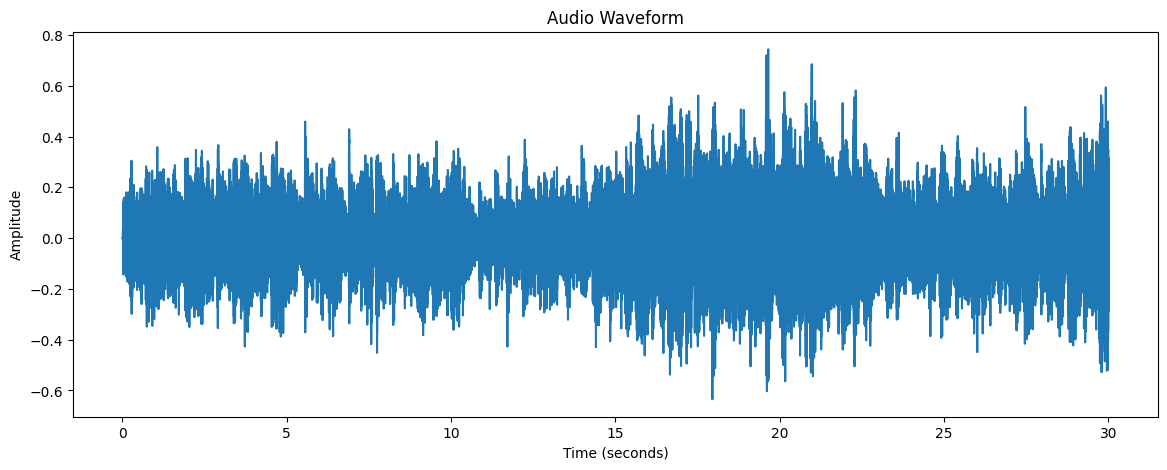

In [12]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

# Load an example audio file
y, sr = librosa.load(audio_files[50])

# Create a time array
time = np.arange(0, len(y)) / sr

# Plot the waveform
plt.figure(figsize=(14, 5))
plt.plot(time, y)
plt.title('Audio Waveform')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()


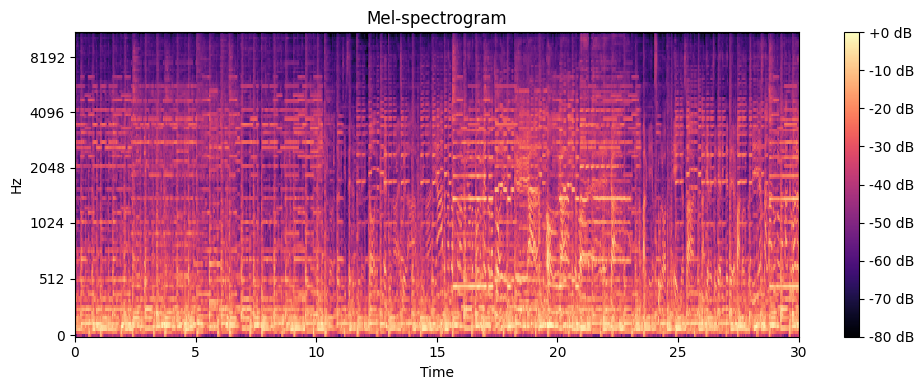

In [13]:
y, sr = librosa.load(audio_files[50], sr=22050)

# Generate Mel-spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512)

# Convert to log scale (dB)
log_S = librosa.power_to_db(S, ref=np.max)

# Plot the Mel-spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel')
plt.title('Mel-spectrogram')
plt.colorbar(format='%+02.0f dB')
plt.tight_layout()
plt.show()

In [5]:
import os

def extract_track_id_from_path(audio_path):
    """
    Extracts the track ID from the audio file path.
    """
    # Get the base name of the file (e.g., '12345.mp3' or 'track_12345_genre.mp3')
    file_name = os.path.basename(audio_path)

    # Scenario 1: If the entire file name (minus extension) is the track ID
    track_id_os = os.path.splitext(file_name)[0]
    formatted_track_id = track_id_os.lstrip('0')
    
    track_id_int = str(formatted_track_id) if formatted_track_id else 0

    return track_id_int

In [6]:
fma_small_tracks['track_id'] = fma_small_tracks['track_id'].astype(str)


/tmp/ipykernel_4924/1952208472.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fma_small_tracks['track_id'] = fma_small_tracks['track_id'].astype(str)


In [7]:
import gc
import numpy as np

mel_spectrograms=[]
num_of_samples=1293
for idx, audio_path in enumerate (audio_files):
    try:
        # Extract track ID from the audio_path 
        track_id = extract_track_id_from_path(audio_path)
        if track_id in fma_small_tracks['track_id'].values:
            genre = fma_small_tracks.loc[fma_small_tracks['track_id'] == track_id, 'track.7'].values[0]
        else:
            print(f"Track ID {track_id} not found in the DataFrame.")
            continue
        
        
        y, sr= librosa.load(audio_path, sr=22050)
        duration=librosa.get_duration(y=y, sr=sr)
        
        if duration>=28:
            S=librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512,n_mels=128, win_length=512)
            log_S=librosa.power_to_db(S, ref=np.max)
            if log_S.shape[1] != num_of_samples:
                log_S = librosa.util.fix_length(log_S, size=num_of_samples, axis=1, constant_values=(0, -80.0))

            mel_spectrograms.append({'track_id': track_id, 'track.7': genre, 'mel_spectrogram':log_S})
        else:
            print(f"File {audio_path} is shorter than 28 seconds")
        
        del y, S, log_S
        gc.collect()
    except Exception as e:
        print( f'Error Processing file {audio_path}: {e}')
        
    if idx % 100==0:
        print(f"Processed {idx} Files")
        
        batch_number = idx // 100
        np.save(f'mel_spectrograms_batch_{batch_number}.npy', mel_spectrograms)
        mel_spectrograms = [] 

Processed 0 Files
Processed 100 Files
Processed 200 Files
Processed 300 Files
Track ID 6674 not found in the DataFrame.
Track ID 6675 not found in the DataFrame.
Track ID 6677 not found in the DataFrame.
Track ID 6679 not found in the DataFrame.
Track ID 6680 not found in the DataFrame.
Track ID 6684 not found in the DataFrame.
Processed 400 Files


[src/libmpg123/layer3.c:INT123_do_layer3():1841] error: dequantization failed!


Processed 500 Files
Processed 600 Files
Processed 700 Files
Processed 800 Files
Processed 900 Files


[src/libmpg123/layer3.c:INT123_do_layer3():1801] error: dequantization failed!


Processed 1000 Files
Processed 1100 Files


...

Error Processing file ./099/099134.mp3: 
Processed 4500 Files
Processed 4600 Files
Processed 4700 Files
Processed 4800 Files
Processed 4900 Files


/tmp/ipykernel_4924/3133396704.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr= librosa.load(audio_path, sr=22050)
[src/libmpg123/parse.c:do_readahead():1099] warning: Cannot read next header, a one-frame stream? Duh...
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/librosa/core/audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error Processing file ./108/108925.mp3: 
Processed 5000 Files
Processed 5100 Files
Processed 5200 Files
Processed 5300 Files
Processed 5400 Files
Processed 5500 Files
Processed 5600 Files
Processed 5700 Files
Processed 5800 Files
Processed 5900 Files
Processed 6000 Files
Processed 6100 Files
Processed 6200 Files
Processed 6300 Files
Processed 6400 Files
Processed 6500 Files
Processed 6600 Files
Processed 6700 Files
Processed 6800 Files
Processed 6900 Files


[src/libmpg123/parse.c:do_readahead():1099] warning: Cannot read next header, a one-frame stream? Duh...
/tmp/ipykernel_4924/3133396704.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr= librosa.load(audio_path, sr=22050)
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/librosa/core/audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error Processing file ./133/133297.mp3: 
Processed 7000 Files
Processed 7100 Files
Processed 7200 Files
Processed 7300 Files
Processed 7400 Files
Processed 7500 Files
Processed 7600 Files
Processed 7700 Files
Processed 7800 Files
Processed 7900 Files
Processed 8000 Files


In [29]:
loaded=np.load('mel_spectrograms_batch_80.npy',allow_pickle=True)
len(loaded)

100

In [1]:
import numpy as np
import os

# Directory where .npy files are stored
npy_directory = '.'

# Initialize a list to store all spectrograms
all_spectrograms = []
all_labels=[]

# Iterate over each .npy file in the directory
for file_name in os.listdir(npy_directory):
    if file_name.endswith('.npy'):
        # Load the current file
        file_path = os.path.join(npy_directory, file_name)
        mel_spectrograms = np.load(file_path, allow_pickle=True)

        # Process each spectrogram in the current file
        for d in mel_spectrograms:
            spectrogram = d['mel_spectrogram']
            all_spectrograms.append(spectrogram)
            all_labels.append(d['track.7'])
            
        

            

# Convert the list of padded spectrograms to a NumPy array

mel_spectrograms_array = np.array(all_spectrograms)


In [2]:
 # Normalization of data In Mel spectogram
mel_spectrograms_normalize = (mel_spectrograms_array - np.min(mel_spectrograms_array)) / (np.max(mel_spectrograms_array) - np.min(mel_spectrograms_array))


In [3]:
#Adding axis to the 2D array
mel_spectrograms_padded= mel_spectrograms_normalize[..., np.newaxis]

In [4]:
from sklearn.preprocessing import LabelEncoder

genres = np.array(all_labels)

# Encode the genre labels
label_encoder = LabelEncoder()
genres_encoded = label_encoder.fit_transform(genres)
len(genres_encoded)

7984

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test_valid, y_train, y_test_valid = train_test_split( mel_spectrograms_padded, genres_encoded, test_size=0.2, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(X_test_valid,y_test_valid ,test_size=0.5)

print(f'Train: {X_train.shape} {y_train.shape}')
print(f'Valid: {x_val.shape}   {y_val.shape}')
print(f'Test:  {x_test.shape}  {y_test.shape}')


Train: (6387, 128, 1293, 1) (6387,)
Valid: (798, 128, 1293, 1)   (798,)
Test:  (799, 128, 1293, 1)  (799,)


In [6]:
from tensorflow.keras import models, layers, optimizers, losses
from tensorflow.keras.callbacks import EarlyStopping

# Create the CNN model
model = models.Sequential()

# Add the first convolutional layer
model.add(layers.Conv2D(36, (3, 4), input_shape=(128, 1293, 1)))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 4)))
model.add(layers.Dropout(0.25))

# Add another convolutional layer
model.add(layers.Conv2D(64, (3, 4)))
model.add(layers.Activation('relu'))          
model.add(layers.MaxPooling2D((2, 4)))
model.add(layers.Dropout(0.25))



# Add a dense layer for classification
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))



model.add(layers.Flatten())

model.add(layers.Dense(len(np.unique(genres_encoded)), activation='softmax'))

optimizer = optimizers.Adam(learning_rate = 0.001)
# Compile the model
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary
model.summary()


2024-01-24 20:20:55.446226: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-01-24 20:20:55.489642: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-01-24 20:20:55.794614: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-01-24 20:20:55.794689: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-01-24 20:20:55.866493: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 1290, 36)     468       
                                                                 
 activation (Activation)     (None, 126, 1290, 36)     0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 322, 36)       0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 63, 322, 36)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 319, 64)       27712     
                                                                 
 activation_1 (Activation)   (None, 61, 319, 64)       0         
                                                        

2024-01-24 20:21:06.729841: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [7]:
epochs = 20
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(x=X_train, 
                    y=y_train,
                    batch_size=64,
                    validation_data=(x_val, y_val),
                    epochs=epochs,
                    shuffle=True,callbacks=[early_stopping])


Epoch 1/20
100/100 [==============================] - 226s 2s/step - loss: 2.0782 - accuracy: 0.2385 - val_loss: 1.8699 - val_accuracy: 0.2870
Epoch 2/20
100/100 [==============================] - 218s 2s/step - loss: 1.7140 - accuracy: 0.3747 - val_loss: 1.6793 - val_accuracy: 0.3747
Epoch 3/20
100/100 [==============================] - 217s 2s/step - loss: 1.6239 - accuracy: 0.4083 - val_loss: 1.5993 - val_accuracy: 0.4411
Epoch 4/20
100/100 [==============================] - 218s 2s/step - loss: 1.5546 - accuracy: 0.4349 - val_loss: 1.5679 - val_accuracy: 0.4198
Epoch 5/20
100/100 [==============================] - 218s 2s/step - loss: 1.4735 - accuracy: 0.4722 - val_loss: 1.5047 - val_accuracy: 0.4787
Epoch 6/20
100/100 [==============================] - 217s 2s/step - loss: 1.3735 - accuracy: 0.5162 - val_loss: 1.4855 - val_accuracy: 0.5050
Epoch 7/20
100/100 [==============================] - 216s 2s/step - loss: 1.2663 - accuracy: 0.5563 - val_loss: 1.4860 - val_accuracy: 0.4724

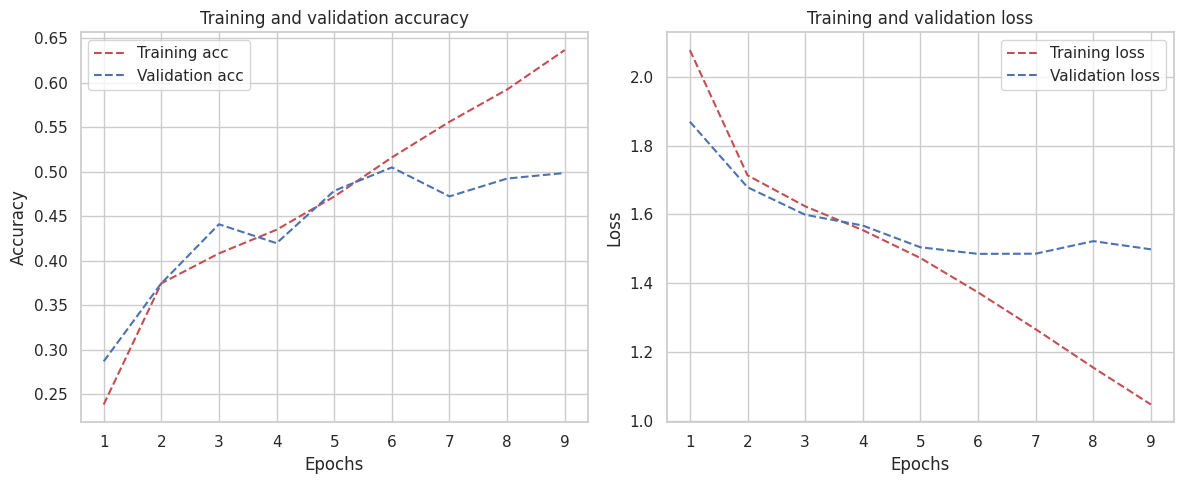

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Set the style of seaborn
sns.set(style='whitegrid')

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r--', label='Training acc')  # Red dashed line for training accuracy
plt.plot(epochs, val_acc, 'b--', label='Validation acc')  # Blue dashed line for validation accuracy
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r--', label='Training loss')  # Red dashed line for training loss
plt.plot(epochs, val_loss, 'b--', label='Validation loss')  # Blue dashed line for validation loss
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
pip freeze > requirements.txt


Note: you may need to restart the kernel to use updated packages.
